In [7]:
# ==========================================================
# Week 1: Data Collection and Cleaning
# AgriInsight
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [8]:
# Load Dataset

df = pd.read_csv("../data/raw/crop_yield.csv")   # Change path if needed

print("Dataset Loaded Successfully\n")

df.head()

Dataset Loaded Successfully



,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [9]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names:\n")
print(df.columns.tolist())

DATASET OVERVIEW
Rows    : 19689
Columns : 10

Column Names:

['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']


In [10]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [11]:
print("First Five Records")
display(df.head())

print("Last Five Records")
display(df.tail())

print("Random Five Records")
display(df.sample(5, random_state=42))

First Five Records


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


Last Five Records


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667
19688,Wheat,1997,Rabi,Jammu and Kashmir,239344.0,392160,1356.2,22778368.48,74196.64,1.261818


Random Five Records


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
18238,Peas & beans (Pulses),2016,Kharif,Jammu and Kashmir,210.00,1010,902.8,32182.500,73.5000,3.820000
6918,Maize,1999,Rabi,Odisha,8270.00,10280,1484.3,877695.100,2232.9000,1.395357
4894,Potato,2016,Winter,Meghalaya,6341.00,44026,3837.1,971758.250,2219.3500,6.522727
10960,Ragi,2008,Autumn,Jharkhand,29768.73,27189,1295.2,4258119.139,2679.1857,0.812857
15615,Castor seed,2017,Kharif,Madhya Pradesh,8950.00,4970,800.0,1409088.000,3401.0000,0.508000


In [12]:
datatype = pd.DataFrame(df.dtypes, columns=["Data Type"])

datatype

,Data Type
Crop,object
Crop_Year,int64
Season,object
State,object
Area,float64
Production,int64
Annual_Rainfall,float64
Fertilizer,float64
Pesticide,float64
Yield,float64


In [13]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Crop,0,0.0
Crop_Year,0,0.0
Season,0,0.0
State,0,0.0
Area,0,0.0
Production,0,0.0
Annual_Rainfall,0,0.0
Fertilizer,0,0.0
Pesticide,0,0.0
Yield,0,0.0


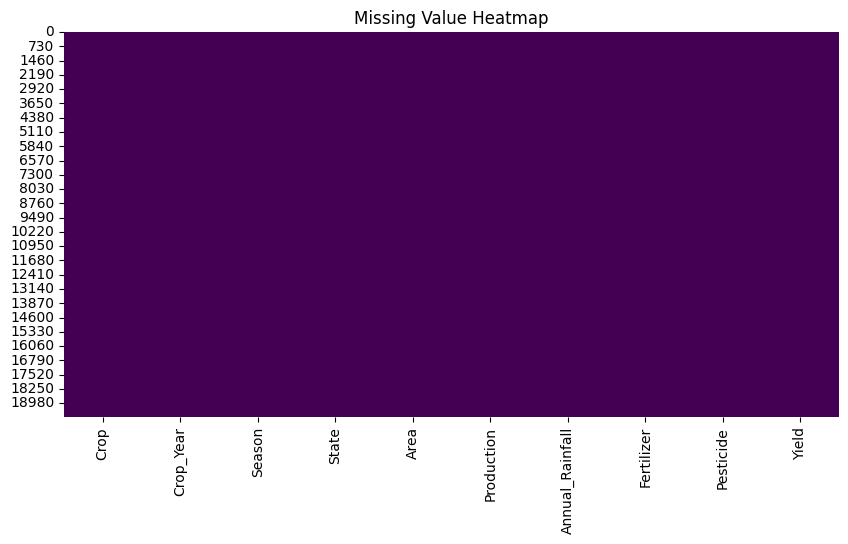

In [14]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Value Heatmap")
plt.show()

In [15]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

if duplicates>0:
    df.drop_duplicates(inplace=True)
    print("Duplicates Removed")
else:
    print("No Duplicate Records Found")

Duplicate Records : 0
No Duplicate Records Found


In [16]:
text_columns = ["Crop","Season","State"]

for col in text_columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.title()

print("Text Columns Standardized")


Text Columns Standardized


In [17]:
for col in ["Crop","Season","State"]:
    print("="*50)
    print(col)
    print("="*50)
    print(df[col].nunique())

Crop
55
Season
6
State
30


In [18]:
numeric_cols = [
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

for col in numeric_cols:

    invalid = df[df[col] < 0]

    print(f"{col} : {len(invalid)} Negative Values")

Area : 0 Negative Values
Production : 0 Negative Values
Annual_Rainfall : 0 Negative Values
Fertilizer : 0 Negative Values
Pesticide : 0 Negative Values
Yield : 0 Negative Values


In [19]:
for col in numeric_cols:

    zeros = (df[col]==0).sum()

    print(f"{col} : {zeros} Zero Values")

Area : 0 Zero Values
Production : 112 Zero Values
Annual_Rainfall : 0 Zero Values
Fertilizer : 0 Zero Values
Pesticide : 0 Zero Values
Yield : 112 Zero Values


In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Crop_Year,19689.0,2.009128e+03,6.498099e+00,1997.00,2004.00,2010.00,2.015000e+03,2.020000e+03
Area,19689.0,1.799266e+05,7.328287e+05,0.50,1390.00,9317.00,7.511200e+04,5.080810e+07
Production,19689.0,1.643594e+07,2.630568e+08,0.00,1393.00,13804.00,1.227180e+05,6.326000e+09
Annual_Rainfall,19689.0,1.437755e+03,8.169096e+02,301.30,940.70,1247.60,1.643700e+03,6.552700e+03
Fertilizer,19689.0,2.410331e+07,9.494600e+07,54.17,188014.62,1234957.44,1.000385e+07,4.835407e+09
Pesticide,19689.0,4.884835e+04,2.132874e+05,0.09,356.70,2421.90,2.004170e+04,1.575051e+07
Yield,19689.0,7.995401e+01,8.783062e+02,0.00,0.60,1.03,2.388889e+00,2.110500e+04


In [21]:
stats_summary = pd.DataFrame()

stats_summary["Mean"] = df.mean(numeric_only=True)

stats_summary["Median"] = df.median(numeric_only=True)

stats_summary["Std Dev"] = df.std(numeric_only=True)

stats_summary["Variance"] = df.var(numeric_only=True)

stats_summary["Skewness"] = df.skew(numeric_only=True)

stats_summary["Kurtosis"] = df.kurtosis(numeric_only=True)

stats_summary

,Mean,Median,Std Dev,Variance,Skewness,Kurtosis
Crop_Year,2.009128e+03,2010.00,6.498099e+00,4.222529e+01,-0.162656,-1.172442
Area,1.799266e+05,9317.00,7.328287e+05,5.370379e+11,21.858218,1202.624968
Production,1.643594e+07,13804.00,2.630568e+08,6.919890e+16,19.299193,388.567239
Annual_Rainfall,1.437755e+03,1247.60,8.169096e+02,6.673413e+05,2.131785,6.974983
Fertilizer,2.410331e+07,1234957.44,9.494600e+07,9.014744e+15,13.412599,408.454102
Pesticide,4.884835e+04,2421.90,2.132874e+05,4.549150e+10,25.635746,1546.727623
Yield,7.995401e+01,1.03,8.783062e+02,7.714218e+05,12.785265,175.577323


In [22]:
print("="*60)
print("OUTLIER ANALYSIS")
print("="*60)

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR

    upper = Q3+1.5*IQR

    outliers = df[(df[col]<lower)|(df[col]>upper)]

    print(f"{col:<20} {len(outliers)} Outliers")

OUTLIER ANALYSIS
Area                 3076 Outliers
Production           3373 Outliers
Annual_Rainfall      1527 Outliers
Fertilizer           3093 Outliers
Pesticide            3036 Outliers
Yield                3065 Outliers


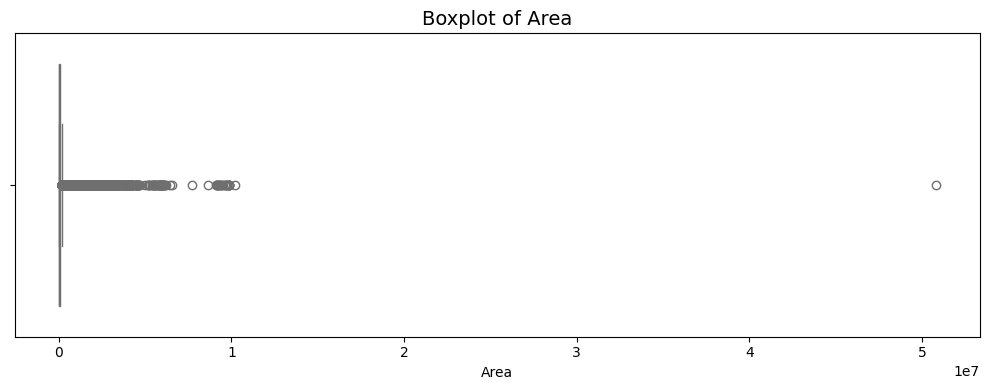

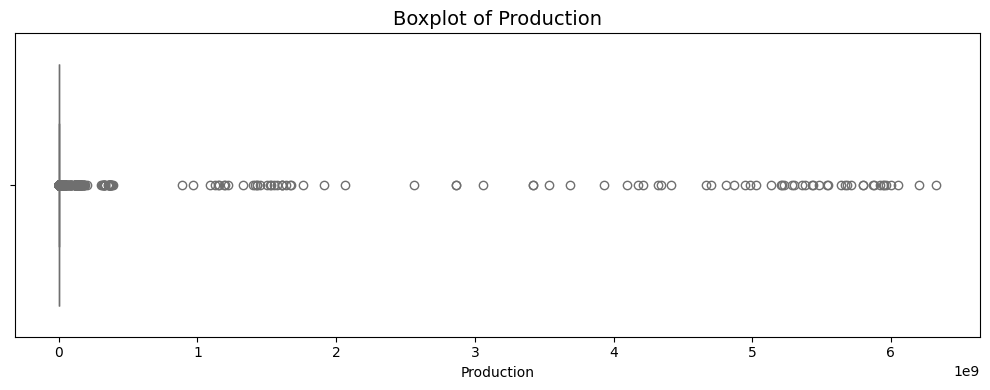

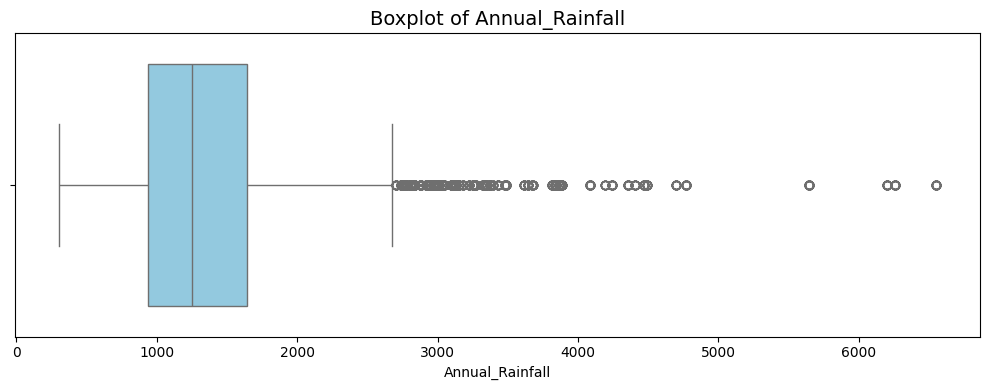

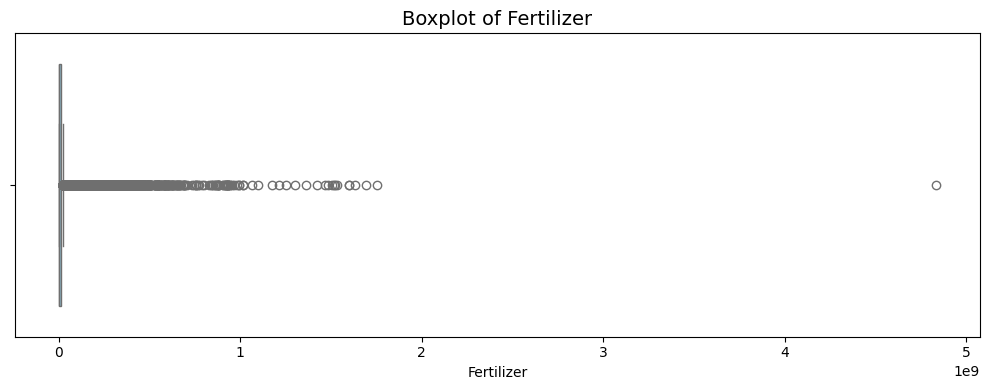

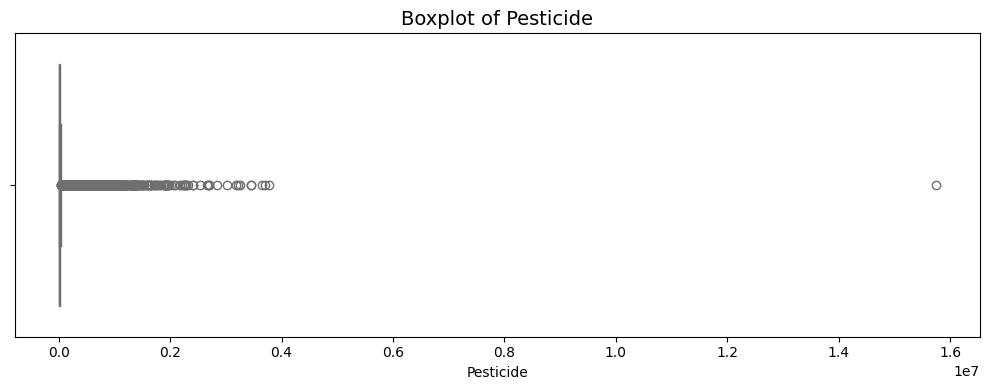

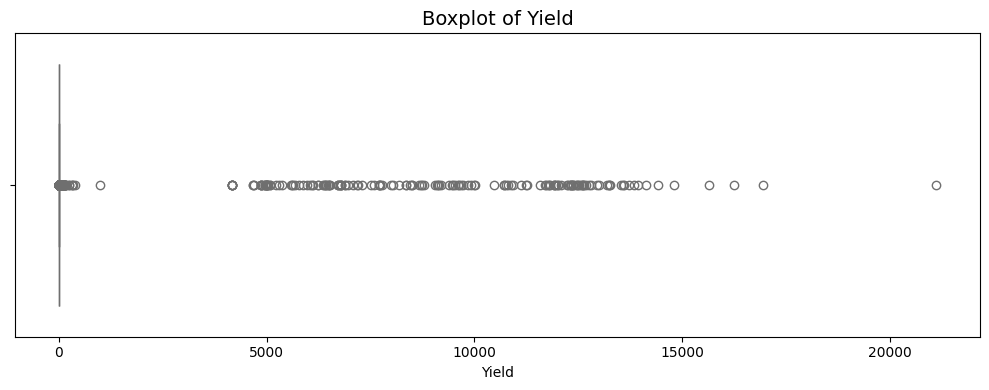

In [23]:
# Numeric columns
numeric_cols = [
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield"
]

# Ensure all numeric columns are actually numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Draw boxplots
for col in numeric_cols:
    plt.figure(figsize=(10, 4))

    sns.boxplot(data=df, x=col, color="skyblue")

    plt.title(f"Boxplot of {col}", fontsize=14)
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [24]:
print("""
Outliers have been detected using the IQR method.

However, they have NOT been removed.

Reason:
Agricultural datasets naturally contain high-value observations due to
differences in cultivated area, production capacity, rainfall,
and farming practices across Indian states.

Removing these observations could result in the loss of meaningful
real-world information and negatively affect subsequent analysis.

Therefore, the detected outliers are retained for further analysis.
""")


Outliers have been detected using the IQR method.

However, they have NOT been removed.

Reason:
Agricultural datasets naturally contain high-value observations due to
differences in cultivated area, production capacity, rainfall,
and farming practices across Indian states.

Removing these observations could result in the loss of meaningful
real-world information and negatively affect subsequent analysis.

Therefore, the detected outliers are retained for further analysis.



In [25]:
from sklearn.preprocessing import MinMaxScaler

scaled_df = df.copy()

scaler = MinMaxScaler()

scaled_df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

scaled_df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,0.001453,8.964274e-06,0.279953,0.001453,0.001453,0.000038
1,Arhar/Tur,1997,Kharif,Assam,0.000131,7.405944e-07,0.279953,0.000131,0.000131,0.000034
2,Castor Seed,1997,Kharif,Assam,0.000016,3.477711e-09,0.279953,0.000016,0.000016,0.000011
3,Coconut,1997,Whole Year,Assam,0.000387,2.006086e-02,0.279953,0.000387,0.000387,0.248190
4,Cotton(Lint),1997,Kharif,Assam,0.000034,1.255138e-07,0.279953,0.000034,0.000034,0.000020


In [27]:
df.to_csv("../data/cleaned/crop_yield_cleaned.csv", index=False)

print("Clean Dataset Saved Successfully")

Clean Dataset Saved Successfully


In [28]:
summary = {
    "Total Rows": len(df),
    "Total Columns": len(df.columns),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Records Removed": duplicates,
    "Negative Values Found": "None",
    "Text Standardized": "Yes",
    "Outliers Removed": "No",
    "Normalization Demonstrated": "Yes",
    "Dataset Ready for EDA": "Yes"
}

pd.DataFrame(summary.items(), columns=["Cleaning Step","Status"])

,Cleaning Step,Status
0,Total Rows,19689
1,Total Columns,10
2,Missing Values,0
3,Duplicate Records Removed,0
4,Negative Values Found,None
5,Text Standardized,Yes
6,Outliers Removed,No
7,Normalization Demonstrated,Yes
8,Dataset Ready for EDA,Yes
